<a href="https://colab.research.google.com/github/isratrimii/Neural-Networks/blob/main/Copy_of_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns


In [ ]:
# DATA PREPROCESSING
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

classes = train_dataset.classes

100%|██████████| 170M/170M [06:33<00:00, 434kB/s]


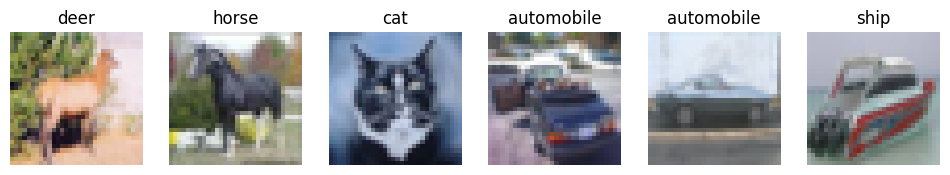

In [ ]:
# VISUALIZE SAMPLE IMAGES
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(12,3))

for i in range(6):

    plt.subplot(1,6,i+1)

    img = example_data[i] / 2 + 0.5

    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1,2,0)))

    plt.title(classes[example_targets[i]])
    plt.axis('off')

plt.show()


In [ ]:
# CNN MODEL
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 8, 3)

        self.conv2 = nn.Conv2d(8, 16, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(16*14*14, 128)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = self.pool(x)

        x = x.view(-1, 16*14*14)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x


In [ ]:
# MODEL SETUP
model = CNN()

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [ ]:
# TRAINING
epochs = 10

train_acc_list = []
test_acc_list = []

train_loss_list = []
test_loss_list = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for data, target in train_loader:

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        outputs = model(data)

        loss = criterion(outputs, target)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += target.size(0)

        correct += (predicted == target).sum().item()

    train_accuracy = 100 * correct / total

    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_accuracy)

    train_loss_list.append(train_loss)

In [ ]:
    # TESTING
    model.eval()

    correct = 0
    total = 0

    running_test_loss = 0

    with torch.no_grad():

        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)

            outputs = model(data)

            loss = criterion(outputs, target)

            running_test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += target.size(0)

            correct += (predicted == target).sum().item()

    test_accuracy = 100 * correct / total

    test_loss = running_test_loss / len(test_loader)

    test_acc_list.append(test_accuracy)

    test_loss_list.append(test_loss)

    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_accuracy:.2f}%")

    print("-"*50)

Epoch [10/10]
Train Loss: 0.5116
Train Accuracy: 81.95%
Test Loss: 1.1662
Test Accuracy: 64.68%
--------------------------------------------------


In [ ]:
# FINAL TEST ACCURACY
print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")


Final Test Accuracy: 64.68%


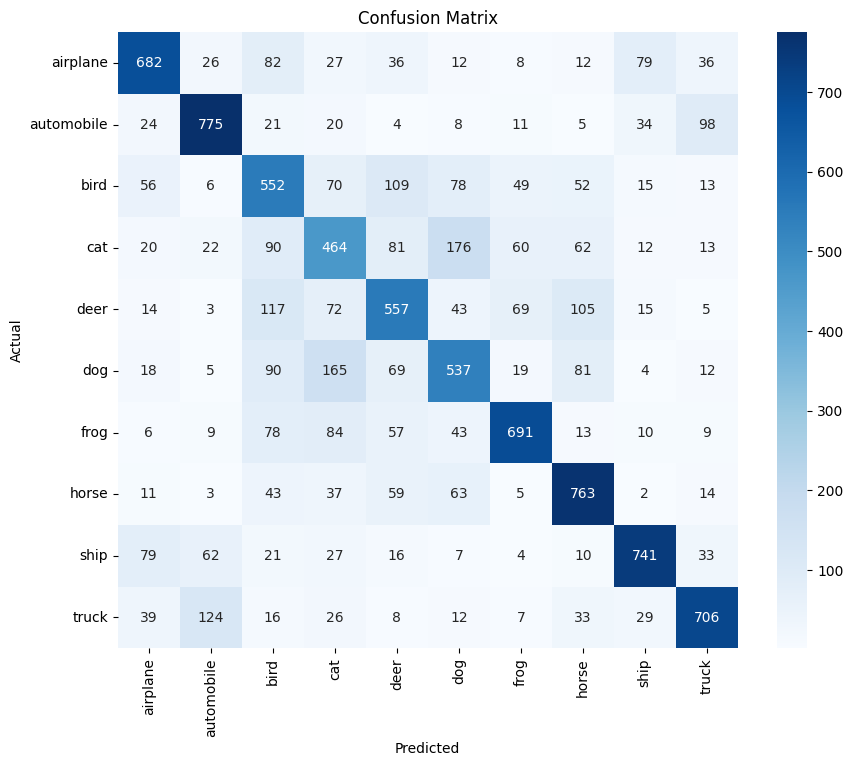

In [ ]:
# CONFUSION MATRIX

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for data, target in test_loader:

        data = data.to(device)

        outputs = model(data)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())

        all_targets.extend(target.numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

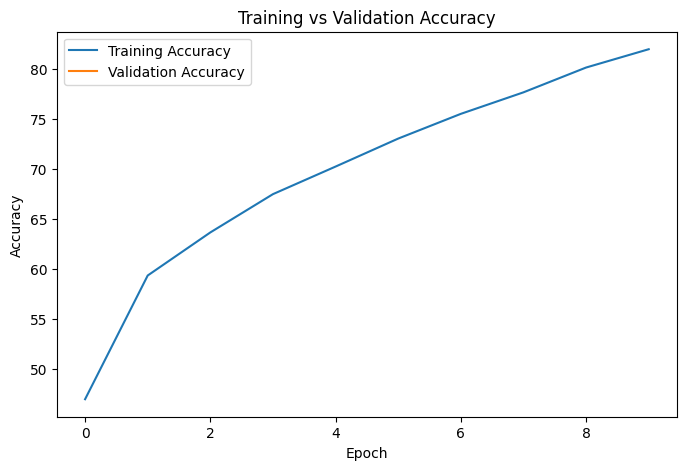

In [ ]:
# ACCURACY GRAPH
plt.figure(figsize=(8,5))

plt.plot(train_acc_list,
         label='Training Accuracy')

plt.plot(test_acc_list,
         label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()


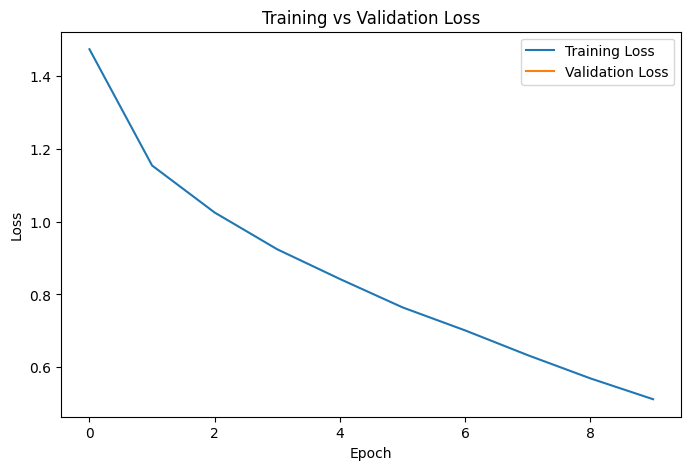

In [ ]:
# LOSS GRAPH
plt.figure(figsize=(8,5))

plt.plot(train_loss_list,
         label='Training Loss')

plt.plot(test_loss_list,
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

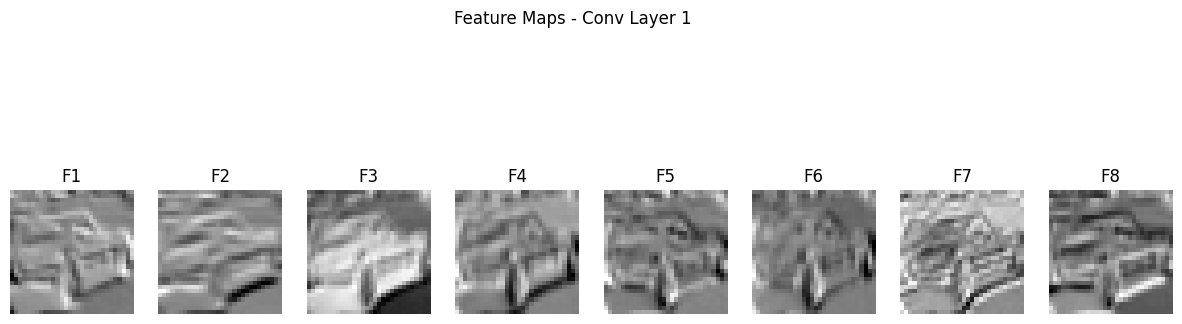

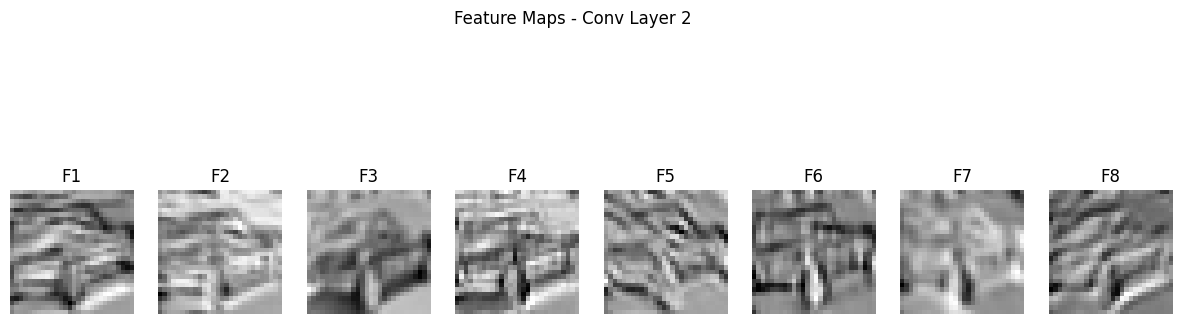

In [ ]:
# FEATURE MAP VISUALIZATION
def get_feature_maps(model, image):

    model.eval()

    outputs = []

    def hook_fn(module, input, output):

        outputs.append(output)

    hooks = []

    for layer in model.children():

        if isinstance(layer, nn.Conv2d):

            hooks.append(
                layer.register_forward_hook(hook_fn)
            )

    with torch.no_grad():

        model(image.unsqueeze(0).to(device))

    for h in hooks:

        h.remove()

    return outputs


sample_img, _ = next(iter(train_loader))

sample_img = sample_img[0]

feature_maps = get_feature_maps(model, sample_img)

for layer_num, fmap in enumerate(feature_maps):

    fmap = fmap.cpu()

    plt.figure(figsize=(15,5))

    num_filters = min(fmap.shape[1], 8)

    for i in range(num_filters):

        plt.subplot(1, num_filters, i+1)

        plt.imshow(
            fmap[0, i].detach().numpy(),
            cmap='gray'
        )

        plt.axis('off')

        plt.title(f'F{i+1}')

    plt.suptitle(
        f'Feature Maps - Conv Layer {layer_num+1}'
    )

    plt.show()